

**Manuscript:** *Balance-Aware Financial Transformers for Coherent Next-Service Prediction*.

This notebook recalculates **Tables 1–5, Figures 1–2, and the quantitative results in Section 4** of the included manuscript. Predictions come from the completed seven-model, five-seed experiment `reproduction_20260918`.

**Execution scope.** Classification and financial metrics are recalculated from 35 saved prediction files. User-clustered confidence intervals and tests are recomputed with 5,000 bootstrap resamples using the supplied evaluator with the numerical correction documented below. Latent analyses use recorded per-sequence measurements and their original seed summaries. Training times are calculated from actual epoch and optimizer-step logs. No training time is simulated. New model fitting is disabled by default; the optional independent-training cell below must be explicitly enabled.

**Run instructions.** Extract the complete ZIP; install `requirements.txt`; open this notebook from that folder and choose **Restart Kernel and Run All Cells**, or run `python execute_notebook.py`. The adjacent `inputs/`, `analysis/`, and `reference_evidence/` folders are required. 

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import ast, hashlib, importlib.util, importlib.metadata, json, os, platform, subprocess, sys, time
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = Path.cwd().resolve()
assert (ROOT / 'inputs/predictions').is_dir(), 'Extract the complete package and open the notebook in its root folder.'
OUT = ROOT / 'outputs'
for folder in ['evidence', 'tables', 'figures', 'logs']:
    (OUT / folder).mkdir(parents=True, exist_ok=True)
STARTED = datetime.now(timezone.utc).isoformat()
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 50)
pd.set_option('display.precision', 6)
pd.set_option('display.max_colwidth', 110)

def load_module(name, relative_path):
    spec = importlib.util.spec_from_file_location(name, ROOT / relative_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

config = json.loads((ROOT / 'inputs/paper_config.json').read_text())
MODELS, SEEDS = config['models'], config['seeds']
LABELS = dict(zip(MODELS, ['GBDT', 'GRU', 'Transformer', 'Time-aware', 'BAFT latent', 'BAFT accounting', 'BAFT full']))
NATIVE = 'validation_gate_native'
PROJECTED = 'validation_gate_hard_projection'
packages = ['numpy', 'pandas', 'scipy', 'scikit-learn', 'pyarrow', 'matplotlib', 'nbformat', 'nbclient', 'ipykernel']
environment = {'started_utc': STARTED, 'python': platform.python_version(), 'platform': platform.platform(),
               'packages': {p: importlib.metadata.version(p) for p in packages},
               'mode': 'Evaluation from saved predictions and recorded measurements; independent training is reported separately.'}
display(pd.DataFrame(environment['packages'].items(), columns=['Evaluation package', 'Version']))
print('Evaluation started:', STARTED)

,Evaluation package,Version
0,numpy,2.2.6
1,pandas,2.3.3
2,scipy,1.15.3
3,scikit-learn,1.7.2
4,pyarrow,21.0.0
5,matplotlib,3.10.8
6,nbformat,5.10.4
7,nbclient,0.10.2
8,ipykernel,7.1.0


Evaluation started: 2026-09-20T21:28:13.839605+00:00


## Dataset and original training code

The complete package includes the **study transaction archive** and the **original model and training source**. Extract the entire package before opening this notebook. 

The study archive contains **3,134,000 transactions from 30,000 users**, as recorded in the dataset. 

The separately labelled synthetic fixture is provided only for software checks. It did not produce the paper's results.

In [2]:
import zipfile

TRAINING = ROOT / 'training'
source_manifest = json.loads((TRAINING / 'training_source_manifest.json').read_text())
for relative, record in source_manifest['files'].items():
    assert sha256(TRAINING / relative) == record['sha256'], f'Changed training input: {relative}'

dataset_manifest = json.loads((TRAINING / 'data/dataset_manifest.json').read_text())
study = next(d for d in dataset_manifest['datasets'] if d['used_for_reported_results'])
DATASET = TRAINING / study['path']
assert sha256(DATASET) == study['sha256'], 'Study dataset checksum does not match.'
assert DATASET.stat().st_size == study['file_size_bytes']
with zipfile.ZipFile(DATASET) as archive:
    assert study['csv_member'] in archive.namelist()
    with archive.open(study['csv_member']) as stream:
        dataset_preview = pd.read_csv(stream, nrows=5)
assert dataset_preview.columns.tolist() == study['columns']

source_checks = []
for name in ['gold_models.py', 'train_gold_neural.py', 'train_gold_gbdt.py']:
    recovered = TRAINING / 'src/baft' / name
    original_copy = ROOT / 'training_source' / name
    assert sha256(recovered) == sha256(original_copy), f'Source mismatch: {name}'
    source_checks.append({'Source': name, 'Match with existing experiment source': 'PASS',
                          'SHA-256': sha256(recovered)})

display(pd.DataFrame([{'Dataset': DATASET.name, 'Recorded transactions': study['rows'],
                       'Recorded users': study['users'], 'Checksum verification': 'PASS'}]))
display(Markdown('**Preview: five rows read from the actual study CSV**'))
display(dataset_preview)
display(pd.DataFrame(source_checks))
access_audit = {'status': 'PASS', 'source_archive': source_manifest['origin_archive'],
                'original_files_verified': len(source_manifest['files']),
                'dataset_path': str(DATASET.relative_to(ROOT)), 'dataset_sha256': sha256(DATASET),
                'preview_rows_read': len(dataset_preview),
                'recorded_dataset_rows': study['rows'], 'recorded_dataset_users': study['users'],
                'counts_source': 'Included dataset manifest; the preview does not recount all rows.',
                'core_source_checks': source_checks}
(OUT / 'dataset_training_access_verification.json').write_text(json.dumps(access_audit, indent=2) + '\n')
print(f'Verified {len(source_manifest["files"])} original training/data/reference files.')

,Dataset,Recorded transactions,Recorded users,Checksum verification
0,mobile_money_dataset_6_month.zip,3134000,30000,PASS


**Preview: five rows read from the actual study CSV**

,USER_ID,COMPLETION_TIME,TAB,SERVICE,AMOUNT,MMT_FEE,BALANCE
0,202000000000200074,03-SEP-25 10.55.48.000000 AM,credit,Cash In,353.0,0.00,353.26
1,202000000000200074,05-SEP-25 09.34.54.000000 AM,debit,Cash out,345.0,6.90,1.36
2,202000000000200074,05-SEP-25 05.56.54.000000 PM,debit,Buy Bundles,1.0,0.00,0.36
3,202000000000200074,19-SEP-25 05.17.28.000000 PM,credit,Send Money,15.0,1.16,15.36
4,202000000000200074,21-SEP-25 07.45.58.000000 PM,debit,Buy Bundles,1.2,0.00,14.16


,Source,Match with existing experiment source,SHA-256
0,gold_models.py,PASS,24a8199910a88de3e4c9aa0ec3edd9c24e809688e5d66998a8713ae946f18ff3
1,train_gold_neural.py,PASS,92439d775c9f0a3faad760459914b036a5f9068016b0b26f5888c967679a0312
2,train_gold_gbdt.py,PASS,bbbc28061786f8fbc722097e4c6527667a3c108f3d4be04156217535cf378121


Verified 68 original training/data/reference files.


### Inspect the training plan

The cell below calls the original launcher with `--dry-run`. It lists the stages and writes their commands to [training_plan.txt](outputs/training_plan.txt). It does **not** fit models or change the supplied evidence.

In [3]:
TRAIN_CONFIG = TRAINING / 'configs/paper.json'
training_config = json.loads(TRAIN_CONFIG.read_text())
assert training_config['models'] == MODELS and training_config['seeds'] == SEEDS
planned_run = TRAINING / 'runs/reviewer_new'
training_command = [sys.executable, str(TRAINING / 'scripts/run_experiments.py'),
                    '--config', str(TRAIN_CONFIG), '--input', str(DATASET),
                    '--output-dir', str(planned_run)]
plan_result = subprocess.run(training_command + ['--dry-run'], cwd=TRAINING,
                             capture_output=True, text=True, check=True)
(OUT / 'training_plan.txt').write_text(plan_result.stdout, encoding='utf-8')
display(pd.DataFrame({'Model': training_config['models'],
                      'Independent seeds': [len(SEEDS)] * len(MODELS)}))
print('Pipeline:', ' -> '.join(training_config['stages']))
print('Seeds:', training_config['seeds'])
print('Training settings:', training_config['training'])
print(plan_result.stdout.splitlines()[-1])
print('Full commands: outputs/training_plan.txt')

,Model,Independent seeds
0,aggregate_gbdt,5
1,gru,5
2,transformer,5
3,time_transformer,5
4,baft_latent,5
5,baft_accounting,5
6,baft_full,5


Pipeline: clean -> validate -> cache -> train -> predictions -> latent -> evidence
Seeds: [20260819, 20260820, 20260821, 20260822, 20260823]
Training settings: {'epochs': 8, 'patience': 8, 'batch_size': 512, 'd_model': 48, 'layers': 1, 'learning_rate': 0.0007, 'eta_train': 0.2}
Dry run only: 41 commands; no data or execution was validated.
Full commands: outputs/training_plan.txt


### Optional: train new models from the dataset

**Leave `RUN_INDEPENDENT_TRAINING = False` to reproduce the saved paper results only.** To train all seven models across five seeds, use a Linux environment (or WSL on Windows) with Python 3.12. The original trainers import the Unix `resource` module and use CPU execution. Install the training dependencies before enabling this cell:

```bash
python -m pip install torch==2.8.0 --index-url https://download.pytorch.org/whl/cpu
python -m pip install -r training/requirements.txt
```

Select that environment as the notebook kernel. Change the flag below to `True` and run the cell. It launches **35 new fits**, plus preprocessing and evaluation, in a new timestamped folder. Logs and checkpoints are retained there. This is separate from the saved-evidence calculations later in this notebook.

The original pipeline remains unchanged. After it completes, the cell also applies the notebook's documented numerical bootstrap correction to the new predictions, saving a separate `results/evidence_corrected/` folder. It does not replace the supplied paper inputs or references. New training can differ across software and hardware environments; the recorded paper timings are not promises about a new run.

For command-line execution, resuming a run, and locating outputs, see [the training guide](training/README.md). With the flag left at `False`, training dependencies are not imported or required by this section.

In [20]:
RUN_INDEPENDENT_TRAINING = False
training_status = {'requested': RUN_INDEPENDENT_TRAINING, 'completed': False,
                   'started_utc': None, 'run_directory': None}
status_path = OUT / 'independent_training_status.json'
status_path.write_text(json.dumps(training_status, indent=2) + '\n')

if not RUN_INDEPENDENT_TRAINING:
    print('Independent training is disabled. The dataset and original source are available in training/.')
else:
    if platform.system() != 'Linux':
        raise RuntimeError('Use Linux or a WSL Python 3.12 kernel for the unchanged original trainers.')
    if sys.version_info[:2] != (3, 12):
        raise RuntimeError('Use the documented Python 3.12 training environment.')
    missing = [p for p in ['torch', 'joblib', 'pyarrow'] if importlib.util.find_spec(p) is None]
    if missing:
        raise RuntimeError('Install training/requirements.txt first. Missing: ' + ', '.join(missing))
    run_id = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
    new_run = TRAINING / 'runs' / ('reviewer_' + run_id)
    train_cmd = [sys.executable, str(TRAINING / 'scripts/run_experiments.py'),
                 '--config', str(TRAIN_CONFIG), '--input', str(DATASET),
                 '--output-dir', str(new_run)]
    training_status.update(started_utc=datetime.now(timezone.utc).isoformat(),
                           run_directory=str(new_run), command=train_cmd)
    status_path.write_text(json.dumps(training_status, indent=2) + '\n')
    print('New run:', new_run, flush=True)
    subprocess.run(train_cmd, cwd=TRAINING, check=True)
    corrected_cmd = [sys.executable, str(ROOT / 'analysis/finalize_evidence_stable.py'),
                     '--runs-dir', str(new_run / 'regenerated/model_runs'),
                     '--cache', str(new_run / 'gold_cache/baft_gold_cache.npz'),
                     '--metadata', str(new_run / 'gold_cache/baft_gold_cache_metadata.json'),
                     '--latent-results', str(new_run / 'results/latent'),
                     '--output-dir', str(new_run / 'results/evidence_corrected'),
                     '--bootstrap-iterations', str(training_config['evidence']['bootstrap_iterations']),
                     '--bootstrap-seed', str(training_config['evidence']['bootstrap_seed'])]
    corrected_env = os.environ.copy()
    for variable in ['OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS']:
        corrected_env[variable] = str(training_config['threads'])
    subprocess.run(corrected_cmd, cwd=TRAINING, env=corrected_env, check=True)
    training_status.update(completed=True, completed_utc=datetime.now(timezone.utc).isoformat(),
                           corrected_evidence=str(new_run / 'results/evidence_corrected'))
    status_path.write_text(json.dumps(training_status, indent=2) + '\n')
    print('New training completed. Supplied paper inputs and references were preserved.')

Independent training is disabled. The dataset and original source are available in training/.


## 1. Verify the evidence inputs



In [5]:
provenance = json.loads((ROOT / 'inputs/source_provenance.json').read_text())
for relative, record in provenance.items():
    assert sha256(ROOT / relative) == record['sha256'], f'Changed input: {relative}'
predictions = sorted((ROOT / 'inputs/predictions').glob('*_gold_test_predictions.npz'))
expected_names = {f'{model}_seed{seed}_gold_test_predictions.npz' for model in MODELS for seed in SEEDS}
assert {p.name for p in predictions} == expected_names
assert len(predictions) == 35
print(f'Verified {len(provenance)} file hashes and all {len(predictions)} model/seed prediction files.')
audit = {'input_hashes_verified': len(provenance), 'prediction_files': len(predictions), 'training_rerun': training_status['completed']}

Verified 208 file hashes and all 35 model/seed prediction files.


## Table 1. Chronological Gold-target partitions

Counts below are calculated from the saved cohort arrays. A user may occur in multiple partitions, so user counts must not be added. The test period is later in time; it is not a wholly unseen-user cohort.

In [6]:
with np.load(ROOT / 'inputs/cohort_index.npz', allow_pickle=False) as cache:
    cohort = {key: cache[key] for key in cache.files}
metadata = json.loads((ROOT / 'inputs/cohort_metadata.json').read_text())
cleaning = json.loads((ROOT / 'inputs/cleaning_metadata.json').read_text())
table1_rows = []
for split_id, label in enumerate(['Training', 'Validation', 'Test']):
    mask = (cohort['split'] == split_id) & (cohort['gold_target'] == 1)
    table1_rows.append({'Partition': label, 'Sequences': int(mask.sum()), 'Users': int(np.unique(cohort['user_code'][mask]).size)})
table1 = pd.DataFrame(table1_rows)
table1.to_csv(OUT / 'tables/table1_partitions.csv', index=False)
display(table1.style.hide(axis='index').format({'Sequences': '{:,}', 'Users': '{:,}'}))
cohort_description = pd.DataFrame([
    ('Source transactions', cleaning['raw_rows']), ('Source users', cleaning['users']),
    ('Candidate sequences', len(cohort['split'])), ('Gold-target sequences', int((cohort['gold_target']==1).sum())),
    ('History events', metadata['history_length']), ('Window stride', cleaning['sequence_protocol']['stride']),
    ('Target service classes', len(metadata['target_services'])),
    ('First recorded timestamp', cleaning['date_min']), ('Last recorded timestamp', cleaning['date_max']),
    ('Training cutoff (inclusive)', cleaning['sequence_protocol']['train_end_inclusive']),
    ('Validation cutoff (inclusive)', cleaning['sequence_protocol']['validation_end_inclusive'])
], columns=['Cohort property', 'Recorded value'])
cohort_description.to_csv(OUT / 'tables/cohort_description.csv', index=False)
display(cohort_description.style.hide(axis='index'))
assert table1['Sequences'].sum() == cleaning['sequence_protocol']['gold_target_sequences']

Partition,Sequences,Users
Training,"19,271","4,985"
Validation,"8,005","4,549"
Test,"8,850","5,253"


Cohort property,Recorded value
Source transactions,3134000
Source users,30000
Candidate sequences,56357
Gold-target sequences,36126
History events,100
Window stride,20
Target service classes,10
First recorded timestamp,2025-09-01 00:00:31
Last recorded timestamp,2026-02-28 23:59:59
Training cutoff (inclusive),2026-01-05 21:48:42


## Table 2. Hyperparameters and the training objective

The table uses the recorded run configuration and the included training source. Attention settings apply to Transformer variants; GRU does not have attention heads, and GBDT has a separate configuration in its run records. The paper's AdamW beta/epsilon values are framework defaults: the original optimizer call explicitly sets the learning rate and weight decay but does not override beta/epsilon. These declared settings are distinguished from measured model performance. The loss coefficients are the full BAFT configuration; disabled controls do not contribute to comparator objectives.

In [7]:
run_records = [json.loads(p.read_text()) for p in sorted((ROOT / 'inputs/model_runs').glob('*.json'))]
neural_records = [r for r in run_records if r['model'] != 'aggregate_gbdt']
assert len(run_records) == 35 and len(neural_records) == 30
hp = neural_records[0]['hyperparameters']
for record in neural_records:
    for key in ['d_model', 'layers', 'batch_size', 'learning_rate', 'max_epochs', 'loss_weights']:
        assert record['hyperparameters'][key] == hp[key], (record['model'], key)
    assert record['hyperparameters']['heads'] == (None if record['model']=='gru' else hp['heads'])
    assert record['epochs_completed'] == 8

model_tree = ast.parse((ROOT / 'training_source/gold_models.py').read_text())
train_tree = ast.parse((ROOT / 'training_source/train_gold_neural.py').read_text())
klass = next(n for n in model_tree.body if isinstance(n, ast.ClassDef) and n.name == 'GoldSequenceModel')
init = next(n for n in klass.body if isinstance(n, ast.FunctionDef) and n.name == '__init__')
defaults = {}
for arg, value in list(zip(init.args.args[-len(init.args.defaults):], init.args.defaults)) + list(zip(init.args.kwonlyargs, init.args.kw_defaults)):
    if value is not None:
        try: defaults[arg.arg] = ast.literal_eval(value)
        except (ValueError, TypeError): pass
optimizer_call = next(n for n in ast.walk(train_tree) if isinstance(n, ast.Call) and ast.unparse(n.func) == 'torch.optim.AdamW')
weight_decay = ast.literal_eval(next(k.value for k in optimizer_call.keywords if k.arg == 'weight_decay'))
clip_call = next(n for n in ast.walk(train_tree) if isinstance(n, ast.Call) and ast.unparse(n.func).endswith('clip_grad_norm_'))
clip_norm = ast.literal_eval(clip_call.args[1])
label_smoothing = next(ast.literal_eval(k.value) for n in ast.walk(model_tree) if isinstance(n, ast.Call) for k in n.keywords if k.arg == 'label_smoothing')
table2 = pd.DataFrame([
    ('History / hidden width / layers', f"{metadata['history_length']} / {hp['d_model']} / {hp['layers']}"),
    ('Attention heads / feed-forward width / dropout', f"{hp['heads']} / {defaults['ff_dim']} / {defaults['dropout']:.2f}"),
    ('Optimizer / learning rate / weight decay', f"AdamW / {hp['learning_rate']:.0e} / {weight_decay:.0e}"),
    ('Adam (beta1, beta2) / epsilon', '(0.9, 0.999) / 1e-8'),
    ('Batch size / epochs / gradient-norm clipping', f"{hp['batch_size']} / {hp['max_epochs']} / {clip_norm:.1f}"),
    ('Service-label smoothing / independent seeds', f"{label_smoothing:.2f} / {len(SEEDS)}")
], columns=['Setting', 'Value'])
table2.to_csv(OUT / 'tables/table2_hyperparameters.csv', index=False)
display(table2.style.hide(axis='index'))
weights = {'service': 1.0, **hp['loss_weights']}
loss_weights = pd.DataFrame(weights.items(), columns=['Loss term', 'Coefficient'])
loss_weights.to_csv(OUT / 'tables/loss_weights.csv', index=False)
display(loss_weights.style.hide(axis='index'))
overview = pd.DataFrame([{'Model': LABELS[r['model']], 'Seed': r['seed'],
                         'Parameters': r.get('parameter_count', np.nan),
                         'Selected epoch': r.get('best_epoch', np.nan),
                         'Epochs completed': r.get('epochs_completed', np.nan)} for r in run_records])
overview.to_csv(OUT / 'tables/all35_run_inventory.csv', index=False)
print('Original fitting hardware:', neural_records[0]['resources']['cpu'])
print('PyTorch:', neural_records[0]['resources']['torch_version'], '| CPU threads:', neural_records[0]['resources']['torch_threads'])
print('Training logs included:', len(list((ROOT / 'inputs/training_logs').glob('train_*.log'))))

Setting,Value
History / hidden width / layers,100 / 48 / 1
Attention heads / feed-forward width / dropout,4 / 96 / 0.10
Optimizer / learning rate / weight decay,AdamW / 7e-04 / 1e-04
"Adam (beta1, beta2) / epsilon","(0.9, 0.999) / 1e-8"
Batch size / epochs / gradient-norm clipping,512 / 8 / 2.0
Service-label smoothing / independent seeds,0.01 / 5


Loss term,Coefficient
service,1.000000
direction,0.120000
amount,0.120000
fee,0.040000
balance,0.100000
accounting,0.040000
feasibility,0.050000
smooth,0.001000
bound,0.001000


Original fitting hardware: AMD EPYC 9V74 80-Core Processor
PyTorch: 2.8.0+cpu | CPU threads: 8
Training logs included: 35


## 2. Recalculate metrics and statistical tests

The following cell runs the evaluation program with numerical tie handling on the 35 prediction files. It computes each seed's metrics separately and then takes the arithmetic mean and sample SD; predictions are not averaged into an ensemble.

The three prediction conditions are **ungated native**, **validation-gated native**, and **validation-gated hard projection**. The paper uses the second for service/financial comparisons and the third for corrected balances. Latent statistics use the original hidden-state measurements.

Confidence intervals resample complete users, preserving all their test sequences. The same 5,000 draws are used across models, seeds and endpoints. Approximate two-sided null-centered bootstrap p-values are Holm-adjusted across the six reported analysis-family endpoints. Accuracy non-inferiority is tested separately across the five paired seeds with a one-percentage-point margin. The resampling analysis conditions on the fitted models.

For each bootstrap draw, the tie allowance is `100 * eps * (abs(left_mean) + abs(right_mean) + 2*abs(observed_effect))`, where `eps` is the float64 machine epsilon. This scale accounts for subtracting the parent means before centering. It is a numerical comparison convention, not a statistical significance threshold or a looser result-validation tolerance. The 5,000 draws and Holm family are unchanged. See `NUMERICAL_CORRECTION.md`.

In [8]:
command = [sys.executable, str(ROOT / 'analysis/finalize_evidence_stable.py'),
           '--runs-dir', str(ROOT / 'inputs/predictions'),
           '--cache', str(ROOT / 'inputs/cohort_index.npz'),
           '--metadata', str(ROOT / 'inputs/cohort_metadata.json'),
           '--latent-results', str(ROOT / 'inputs/latent'),
           '--output-dir', str(OUT / 'evidence'),
           '--bootstrap-iterations', str(config['evidence']['bootstrap_iterations']),
           '--bootstrap-seed', str(config['evidence']['bootstrap_seed'])]
child_env = os.environ.copy()
for name in ['OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS']:
    child_env[name] = str(config['threads'])
evaluation_started = time.perf_counter()
result = subprocess.run(command, cwd=ROOT, env=child_env, capture_output=True, text=True)
(OUT / 'logs/evaluation.log').write_text(result.stdout + '\n' + result.stderr)
assert result.returncode == 0, (OUT / 'logs/evaluation.log').read_text()[-6000:]
evaluation_seconds = time.perf_counter() - evaluation_started
print(f'Evaluation finished successfully in {evaluation_seconds:.2f} seconds.')
print("This duration is notebook evaluation time, not the paper's training time.")
frozen = pd.read_csv(OUT / 'evidence/frozen_results_table.csv')
seeds = pd.read_csv(OUT / 'evidence/seed_metrics_long.csv')
effects = pd.read_csv(OUT / 'evidence/paired_effects_and_tests.csv')
print(f'Recalculated {len(frozen)} summaries from {len(seeds)} seed-level metrics.')
audit['evaluation_seconds'] = evaluation_seconds
audit['bootstrap_resamples'] = config['evidence']['bootstrap_iterations']

Evaluation finished successfully in 13.99 seconds.
This duration is notebook evaluation time, not the paper's training time.
Recalculated 477 summaries from 2385 seed-level metrics.


## 3. Verify the recomputation and disclose the numerical correction

All unchanged numerical fields are still checked against the original evidence at `rtol=atol=1e-10`. For the paired-tests file, the revised bootstrap p-values are checked against a separately identified corrected reference, which was independently recomputed using one and eight numerical-library threads. The original reference remains available, and every p-value change is exported and displayed. Unexpected changes still stop execution and produce `outputs/verification_mismatches.csv`; no blanket tolerance increase is used.

In [9]:
checks = []
CORRECTED_P_COLUMNS = {'cluster_centered_bootstrap_p','cluster_centered_bootstrap_p_holm'}

def compare_numeric(name, keys):
    current = pd.read_csv(OUT / 'evidence' / name).set_index(keys).sort_index()
    original = pd.read_csv(ROOT / 'reference_evidence' / name).set_index(keys).sort_index()
    assert current.index.equals(original.index), f'{name}: row keys differ'
    assert current.index.is_unique and original.index.is_unique, f'{name}: duplicate row keys'
    numeric = original.select_dtypes(include='number').columns
    assert set(numeric).issubset(current.columns), f'{name}: required numeric columns missing'
    corrected = None
    if name == 'paired_effects_and_tests.csv':
        corrected = pd.read_csv(ROOT / 'corrected_reference_evidence' / name).set_index(keys).sort_index()
        assert corrected.index.equals(original.index)
        for column in numeric:
            if column not in CORRECTED_P_COLUMNS:
                np.testing.assert_allclose(corrected[column],original[column],rtol=1e-10,atol=1e-10,equal_nan=True)
    mismatches, corrections = [], []
    for column in numeric:
        expected = corrected[column] if corrected is not None and column in CORRECTED_P_COLUMNS else original[column]
        a,b = current[column].to_numpy(float),expected.to_numpy(float)
        bad = ~np.isclose(a,b,rtol=1e-10,atol=1e-10,equal_nan=True)
        for position in np.flatnonzero(bad):
            record=dict(zip(keys,current.index[position]))
            record.update(file=name,column=column,actual=a[position],expected=b[position])
            mismatches.append(record)
        if corrected is not None and column in CORRECTED_P_COLUMNS:
            changed = ~np.isclose(corrected[column],original[column],rtol=1e-10,atol=1e-10,equal_nan=True)
            for position in np.flatnonzero(changed):
                record=dict(zip(keys,current.index[position]))
                record.update(column=column,archived_value=original[column].iloc[position],corrected_value=corrected[column].iloc[position])
                corrections.append(record)
    if mismatches:
        report = pd.DataFrame(mismatches)
        report.to_csv(OUT / 'verification_mismatches.csv',index=False)
        display(report.head(30))
        raise AssertionError(f'{name}: {len(report)} unexpected differences. See outputs/verification_mismatches.csv and outputs/runtime_environment_diagnostic.json.')
    if corrected is not None:
        correction_report = pd.DataFrame(corrections)
        correction_report.to_csv(OUT / 'tables/bootstrap_p_corrections.csv',index=False)
        audit['documented_bootstrap_p_corrections'] = len(correction_report)
    checks.append({'File':name,'Rows verified':len(current),'Numerical columns':len(numeric),
                   'Reference':'Original plus disclosed p-value correction' if corrected is not None else 'Original',
                   'Status':'PASS'})

(OUT / 'runtime_environment_diagnostic.json').write_text(json.dumps(environment,indent=2)+'\n')
(OUT / 'verification_mismatches.csv').unlink(missing_ok=True)
compare_numeric('frozen_results_table.csv', ['model', 'condition', 'metric'])
compare_numeric('seed_metrics_long.csv', ['model', 'seed', 'condition', 'metric'])
compare_numeric('paired_effects_and_tests.csv', ['reference', 'comparator', 'condition', 'metric'])
compare_numeric('constraint_transfer_effects.csv', ['model', 'from_condition', 'to_condition', 'metric'])
compare_numeric('validation_selected_eta.csv', ['model', 'seed'])
verification = pd.DataFrame(checks)
display(verification.style.hide(axis='index'))
verification.to_csv(OUT / 'tables/evidence_verification.csv',index=False)
audit['reference_comparisons'] = checks
print('Original inputs and non-bootstrap-p statistical fields verified. All bootstrap p-value changes are explicitly reported.')
lookup = frozen.set_index(['model', 'condition', 'metric'])
def item(model, metric, condition=NATIVE):
    return lookup.loc[(model, condition, metric)]
def mean_sd(model, metric, condition=NATIVE, scale=1):
    r = item(model, metric, condition)
    return f"{scale*r['estimate']:.2f} ± {scale*r['seed_sd']:.2f}"

def style_model_table(frame, column_specs):
    styles = pd.DataFrame('', index=frame.index, columns=frame.columns)
    for column, metric, condition, scale in column_specs:
        rows = {m: item(m, metric, condition) for m in MODELS if (m, condition, metric) in lookup.index}
        direction = next(iter(rows.values()))['better_direction']
        best = (min if direction == 'lower' else max)(r['estimate'] for r in rows.values())
        comparator = rows['transformer']['estimate']
        for model, r in rows.items():
            css = 'font-weight: bold;' if np.isclose(r['estimate'], best, atol=1e-12, rtol=0) else ''
            delta = r['estimate'] - comparator
            better = delta < -1e-12 if direction == 'lower' else delta > 1e-12
            if model.startswith('baft_') and better: css += 'background-color: #e2f1ea;'
            styles.loc[LABELS[model], column] = css
    return frame.style.apply(lambda _: styles, axis=None).set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]},
        {'selector': 'td', 'props': [('padding', '6px 10px')]}
    ])

File,Rows verified,Numerical columns,Reference,Status
frozen_results_table.csv,477,7,Original,PASS
seed_metrics_long.csv,2385,1,Original,PASS
paired_effects_and_tests.csv,408,21,Original plus disclosed p-value correction,PASS
constraint_transfer_effects.csv,266,6,Original,PASS
validation_selected_eta.csv,35,1,Original,PASS


Original inputs and non-bootstrap-p statistical fields verified. All bootstrap p-value changes are explicitly reported.


## Table 3. Prediction and affordability

Percentages are **mean ± sample SD across five independent seeds**, after validation-selected feasibility gating. Higher is better except ECE. Bold identifies the best mean; pale green identifies a BAFT mean better than the standard Transformer, descriptively. Green alone does not imply statistical significance.

In [10]:
spec3 = [('Accuracy (%)','accuracy',NATIVE,100), ('Macro-F1 (%)','macro_f1',NATIVE,100),
         ('Top-3 (%)','top3',NATIVE,100), ('Feasible (%)','predicted_feasible_rate',NATIVE,100),
         ('FVA (%)','financially_valid_accuracy',NATIVE,100), ('ECE (%)','ece',NATIVE,100)]
table3 = pd.DataFrame({column: [mean_sd(m, metric, condition, scale) for m in MODELS]
                       for column,metric,condition,scale in spec3}, index=[LABELS[m] for m in MODELS])
table3.index.name = 'Model'
table3.to_csv(OUT / 'tables/table3_prediction.csv')
display(style_model_table(table3, spec3))

,Accuracy (%),Macro-F1 (%),Top-3 (%),Feasible (%),FVA (%),ECE (%)
Model,,,,,,
GBDT,56.38 ± 0.28,39.34 ± 0.53,84.88 ± 0.25,98.42 ± 0.10,55.47 ± 0.31,1.74 ± 0.34
GRU,55.32 ± 0.19,36.55 ± 0.66,83.60 ± 0.15,94.53 ± 0.51,52.54 ± 0.42,3.35 ± 0.54
Transformer,54.66 ± 0.36,36.13 ± 0.96,83.02 ± 0.47,94.73 ± 0.67,51.84 ± 0.58,1.92 ± 0.23
Time-aware,54.71 ± 0.32,36.72 ± 0.48,83.25 ± 0.25,95.44 ± 0.82,52.39 ± 0.57,1.89 ± 0.42
BAFT latent,54.72 ± 0.25,36.33 ± 0.54,83.04 ± 0.23,95.14 ± 0.73,52.22 ± 0.43,1.87 ± 0.08
BAFT accounting,54.50 ± 0.31,36.24 ± 0.39,82.99 ± 0.25,95.12 ± 0.62,51.90 ± 0.37,2.00 ± 0.31
BAFT full,54.60 ± 0.26,36.03 ± 0.48,82.96 ± 0.26,94.84 ± 0.54,52.01 ± 0.29,1.94 ± 0.34


## Table 4. Native and projected financial outputs and latent stability

Service selection uses validation-selected gates. Native balances are the model's unprojected predictions. Hard projection replaces only the selected balance with the hard-direction accounting identity. It does not change service ranking or enforce affordability. Latent measurements come from the original hidden states. GBDT has no comparable sequential hidden trajectory, so its latent acceleration is **n/a**.

Lower is better in every column. Monetary errors retain the source dataset's monetary scale; this notebook does not infer a currency or perform an exchange-rate conversion.

In [11]:
spec4 = [('Balance MAE: native','balance_mae',NATIVE,1),
         ('Balance MAE: projected','balance_mae',PROJECTED,1),
         ('Residual MAE: native','operational_accounting_residual_mae',NATIVE,1),
         ('Latent acceleration MSE','latent_acceleration_mse','latent_native',1)]
table4 = pd.DataFrame({column: [mean_sd(m, metric, condition, scale) if (m,condition,metric) in lookup.index else 'n/a'
                               for m in MODELS] for column,metric,condition,scale in spec4},
                      index=[LABELS[m] for m in MODELS])
table4.index.name = 'Model'
table4.to_csv(OUT / 'tables/table4_financial_latent.csv')
display(style_model_table(table4, spec4))

,Balance MAE: native,Balance MAE: projected,Residual MAE: native,Latent acceleration MSE
Model,,,,
GBDT,60.31 ± 0.44,53.85 ± 0.14,22.07 ± 0.94,n/a
GRU,163.19 ± 7.69,55.66 ± 0.39,152.80 ± 8.89,4.07 ± 0.64
Transformer,163.90 ± 12.25,55.86 ± 0.34,150.22 ± 13.90,25.21 ± 1.16
Time-aware,155.46 ± 6.23,56.46 ± 0.58,139.79 ± 7.20,25.14 ± 1.31
BAFT latent,157.61 ± 7.24,56.25 ± 0.52,142.81 ± 8.31,2.08 ± 0.39
BAFT accounting,54.99 ± 0.84,55.17 ± 0.26,9.43 ± 1.37,25.96 ± 1.30
BAFT full,54.68 ± 0.37,55.10 ± 0.33,9.75 ± 0.95,2.19 ± 0.46


## Table 5. Paired BAFT–Transformer effects

Effects are **BAFT full minus Transformer**. Accuracy/FVA use percentage points. Confidence intervals are paired user-clustered 95% percentile intervals. The displayed adjusted p-values are from the approximate null-centered bootstrap test with Holm correction across six endpoints, including bound excess.

Cohen's $d_z$ is the mean paired seed difference divided by its sample SD. It is based on five seed pairs, not 5,253 independent training runs. Negative effects are favorable for errors. A confidence interval crossing zero does not demonstrate equality; the non-inferiority test is reported separately.

The table uses the corrected inclusive numerical-tie convention. The comparison immediately below identifies manuscript p-values that must be updated; effect sizes and confidence intervals remain unchanged within the strict numerical checks.

In [12]:
spec5 = [('Accuracy','accuracy',NATIVE,100,3), ('FVA','financially_valid_accuracy',NATIVE,100,3),
         ('Residual MAE','operational_accounting_residual_mae',NATIVE,1,2),
         ('Balance MAE','balance_mae',NATIVE,1,2),
         ('Latent accel. MSE','latent_acceleration_mse','latent_native',1,2)]
effect_rows, supported = [], []
for label,metric,condition,scale,dp in spec5:
    r = effects[(effects['reference']=='baft_full') & (effects['comparator']=='transformer') &
                (effects['condition']==condition) & (effects['metric']==metric)].iloc[0]
    p = r['cluster_centered_bootstrap_p_holm']
    effect_rows.append({'Endpoint':label, 'Difference':f"{scale*r['absolute_effect']:+.{dp}f}",
                        'User-clustered 95% CI':f"[{scale*r['user_effect_ci95_low']:.{dp}f}, {scale*r['user_effect_ci95_high']:.{dp}f}]",
                        'Cohen dz':f"{r['cohen_dz']:.2f}", 'Holm-adjusted p':f'{p:.4f}' if p < .01 else f'{p:.3f}'})
    direction = item('baft_full',metric,condition)['better_direction']
    supported.append(p < .05 and (r['user_effect_ci95_high'] < 0 if direction=='lower' else r['user_effect_ci95_low'] > 0))
table5 = pd.DataFrame(effect_rows)
table5.to_csv(OUT / 'tables/table5_effects.csv', index=False)
display(table5.style.hide(axis='index').apply(lambda row: ['background-color: #e2f1ea; font-weight: bold;' if supported[row.name] else '' for _ in row], axis=1))
ni = effects[(effects['reference']=='baft_full') & (effects['comparator']=='transformer') &
             (effects['condition']==NATIVE) & (effects['metric']=='accuracy')].iloc[0]
print(f"Separate one-sided paired-seed non-inferiority test: margin = {100*ni['noninferiority_margin']:.1f} pp; p = {ni['noninferiority_seed_t_p_one_sided']:.4f}.")
archived_effects = pd.read_csv(ROOT / 'reference_evidence/paired_effects_and_tests.csv')
correction_rows=[]
for label,metric,condition,scale,dp in spec5:
    old = archived_effects[(archived_effects['reference']=='baft_full') & (archived_effects['comparator']=='transformer') & (archived_effects['condition']==condition) & (archived_effects['metric']==metric)].iloc[0]
    new = effects[(effects['reference']=='baft_full') & (effects['comparator']=='transformer') & (effects['condition']==condition) & (effects['metric']==metric)].iloc[0]
    oldp,newp=old['cluster_centered_bootstrap_p_holm'],new['cluster_centered_bootstrap_p_holm']
    fmt=lambda p:f'{p:.4f}' if p < .01 else f'{p:.3f}'
    correction_rows.append({'Endpoint':label,'Archived paper p':fmt(oldp),'Corrected p':fmt(newp),
                            'Manuscript update required':fmt(oldp)!=fmt(newp),
                            'Decision at alpha=0.05 unchanged':bool((oldp<.05)==(newp<.05))})
paper_corrections=pd.DataFrame(correction_rows)
paper_corrections.to_csv(OUT / 'tables/table5_manuscript_corrections.csv',index=False)
display(paper_corrections.style.hide(axis='index'))
assert paper_corrections['Decision at alpha=0.05 unchanged'].all()

Endpoint,Difference,User-clustered 95% CI,Cohen dz,Holm-adjusted p
Accuracy,-0.066,"[-0.343, 0.204]",-0.18,0.641
FVA,+0.176,"[-0.126, 0.485]",0.26,0.508
Residual MAE,-140.47,"[-154.44, -128.02]",-10.38,0.0012
Balance MAE,-109.23,"[-122.30, -97.83]",-9.18,0.0012
Latent accel. MSE,-23.02,"[-24.35, -21.81]",-16.95,0.0012


Separate one-sided paired-seed non-inferiority test: margin = 1.0 pp; p = 0.0023.


Endpoint,Archived paper p,Corrected p,Manuscript update required,Decision at alpha=0.05 unchanged
Accuracy,0.639,0.641,True,True
FVA,0.507,0.508,True,True
Residual MAE,0.0012,0.0012,False,True
Balance MAE,0.0012,0.0012,False,True
Latent accel. MSE,0.0012,0.0012,False,True


## Figure 1. Component ablation

Both panels use the same time-aware backbone with latent and financial controls enabled or disabled. Means and sample SDs are computed from the five seeds. Lines connect discrete configurations, not training epochs. Reducing latent acceleration measures smoother representations; it does not establish that real financial behavior must change gradually.

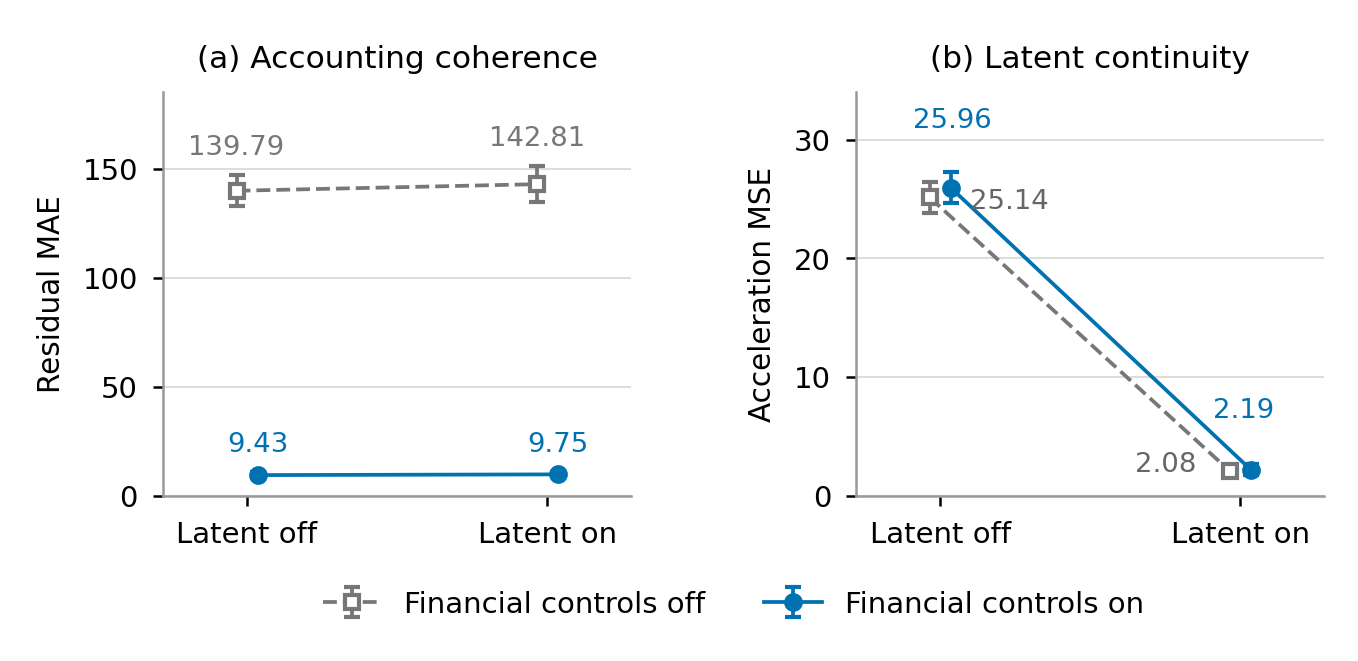

Accuracy range across the four ablation configurations: 0.22 percentage points.


In [13]:
plots = load_module('paper_plots', 'analysis/paper_plots.py')
figure1 = plots.plot_ablation(frozen, OUT / 'figures')
display(Image(filename=str(figure1['png']), width=850))
ablation_models = ['time_transformer','baft_latent','baft_accounting','baft_full']
ablation = pd.DataFrame({'Model':[LABELS[m] for m in ablation_models],
                        'Accuracy (%)':[100*item(m,'accuracy')['estimate'] for m in ablation_models],
                        'Residual MAE':[item(m,'operational_accounting_residual_mae')['estimate'] for m in ablation_models],
                        'Latent acceleration MSE':[item(m,'latent_acceleration_mse','latent_native')['estimate'] for m in ablation_models]})
ablation.to_csv(OUT / 'tables/figure1_ablation_values.csv', index=False)
print(f"Accuracy range across the four ablation configurations: {ablation['Accuracy (%)'].max()-ablation['Accuracy (%)'].min():.2f} percentage points.")

## 4. Hard-projection analysis

Projection uses the selected direction, amount and fee to replace the balance. The next cell verifies the zero accounting residual and unchanged service/affordability metrics for all seven models. The accounting identity is satisfied by construction; this does not establish that a debit is affordable.

In [14]:
unchanged_metrics = ['accuracy','macro_f1','top3','predicted_feasible_rate','financially_valid_accuracy','ece']
projection_rows = []
for model in MODELS:
    for metric in unchanged_metrics:
        np.testing.assert_allclose(item(model,metric,NATIVE)['estimate'], item(model,metric,PROJECTED)['estimate'], atol=1e-12, rtol=0)
    assert item(model,'operational_accounting_residual_mae',PROJECTED)['estimate'] == 0
    projection_rows.append({'Model':LABELS[model], 'Native balance MAE':item(model,'balance_mae',NATIVE)['estimate'],
                            'Projected balance MAE':item(model,'balance_mae',PROJECTED)['estimate'],
                            'Projected residual MAE':item(model,'operational_accounting_residual_mae',PROJECTED)['estimate']})
projection = pd.DataFrame(projection_rows)
projection.to_csv(OUT / 'tables/projection_analysis.csv', index=False)
display(projection.style.hide(axis='index').format(precision=2))
audit['projection_invariance_all_seven_models'] = True

Model,Native balance MAE,Projected balance MAE,Projected residual MAE
GBDT,60.31,53.85,0.00
GRU,163.19,55.66,0.00
Transformer,163.90,55.86,0.00
Time-aware,155.46,56.46,0.00
BAFT latent,157.61,56.25,0.00
BAFT accounting,54.99,55.17,0.00
BAFT full,54.68,55.10,0.00


## 5. Recorded training cost and sequence-length scaling

Epoch costs include optimization, validation inference and validation gate search at batch size 512. The length-scaling experiment measures optimizer steps at batch size 128 for 25, 50, 75 and 100 events. Each of five trials has three warm-up and five timed steps; plotted values are the mean and sample SD of the five trial medians.

These are different timing scopes. This cell reaggregates the recorded observations and does not claim to have remeasured the historical execution times. The original training logs and all raw step measurements are included.

In [15]:
timing = load_module('recorded_timing', 'analysis/recorded_timing.py')
epoch_records, epoch_summary_rows, total_rows = timing.collect_epochs(ROOT / 'inputs/timing')
scaling_rows, scaling_protocol = timing.collect_scalability(ROOT / 'inputs/scaling')
epoch_summary = pd.DataFrame(epoch_summary_rows)
scaling = pd.DataFrame(scaling_rows)
epoch_summary.to_csv(OUT / 'tables/figure2_epoch_summary.csv', index=False)
scaling.to_csv(OUT / 'tables/figure2_scaling_values.csv', index=False)
pd.DataFrame(epoch_records).to_csv(OUT / 'tables/all_recorded_epochs.csv', index=False)
pd.DataFrame(total_rows).to_csv(OUT / 'tables/training_run_totals.csv', index=False)
training_cost = epoch_summary[epoch_summary['epoch']==8][['model','cumulative_seconds_mean','cumulative_seconds_sample_sd']].copy()
training_cost['Model'] = training_cost['model'].map(LABELS)
training_cost['Eight epochs (s)'] = training_cost.apply(lambda r: f"{r['cumulative_seconds_mean']:.2f} ± {r['cumulative_seconds_sample_sd']:.2f}",axis=1)
display(training_cost[['Model','Eight epochs (s)']].style.hide(axis='index'))
length100 = scaling[scaling['history_length']==100].copy()
length100['Model'] = length100['model'].map(LABELS)
length100['Training step at 100 events (ms)'] = length100.apply(lambda r:f"{r['mean_trial_median_ms']:.2f} ± {r['sample_sd_trial_median_ms']:.2f}",axis=1)
display(length100[['Model','Training step at 100 events (ms)']].style.hide(axis='index'))
assert len(epoch_records)==240 and len(epoch_summary)==48 and len(scaling)==24
audit.update(recorded_epochs=240, scaling_points=24, timed_optimizer_steps=600, warmup_optimizer_steps=360)

Model,Eight epochs (s)
GRU,61.52 ± 1.02
Transformer,143.57 ± 4.26
Time-aware,243.43 ± 3.12
BAFT latent,248.53 ± 4.53
BAFT accounting,363.23 ± 77.40
BAFT full,345.26 ± 5.45


Model,Training step at 100 events (ms)
GRU,60.54 ± 5.74
Transformer,109.96 ± 5.54
Time-aware,174.68 ± 10.42
BAFT latent,182.56 ± 4.34
BAFT accounting,177.34 ± 5.95
BAFT full,196.28 ± 34.16


## Figure 2. Training efficiency and measured scaling

Bands and error bars are sample standard deviations, not confidence intervals. GBDT is omitted because it has no comparable neural epoch trajectory. The measurements support CPU timing comparisons over the tested lengths; they do not establish performance at longer histories or accuracy for shorter histories.

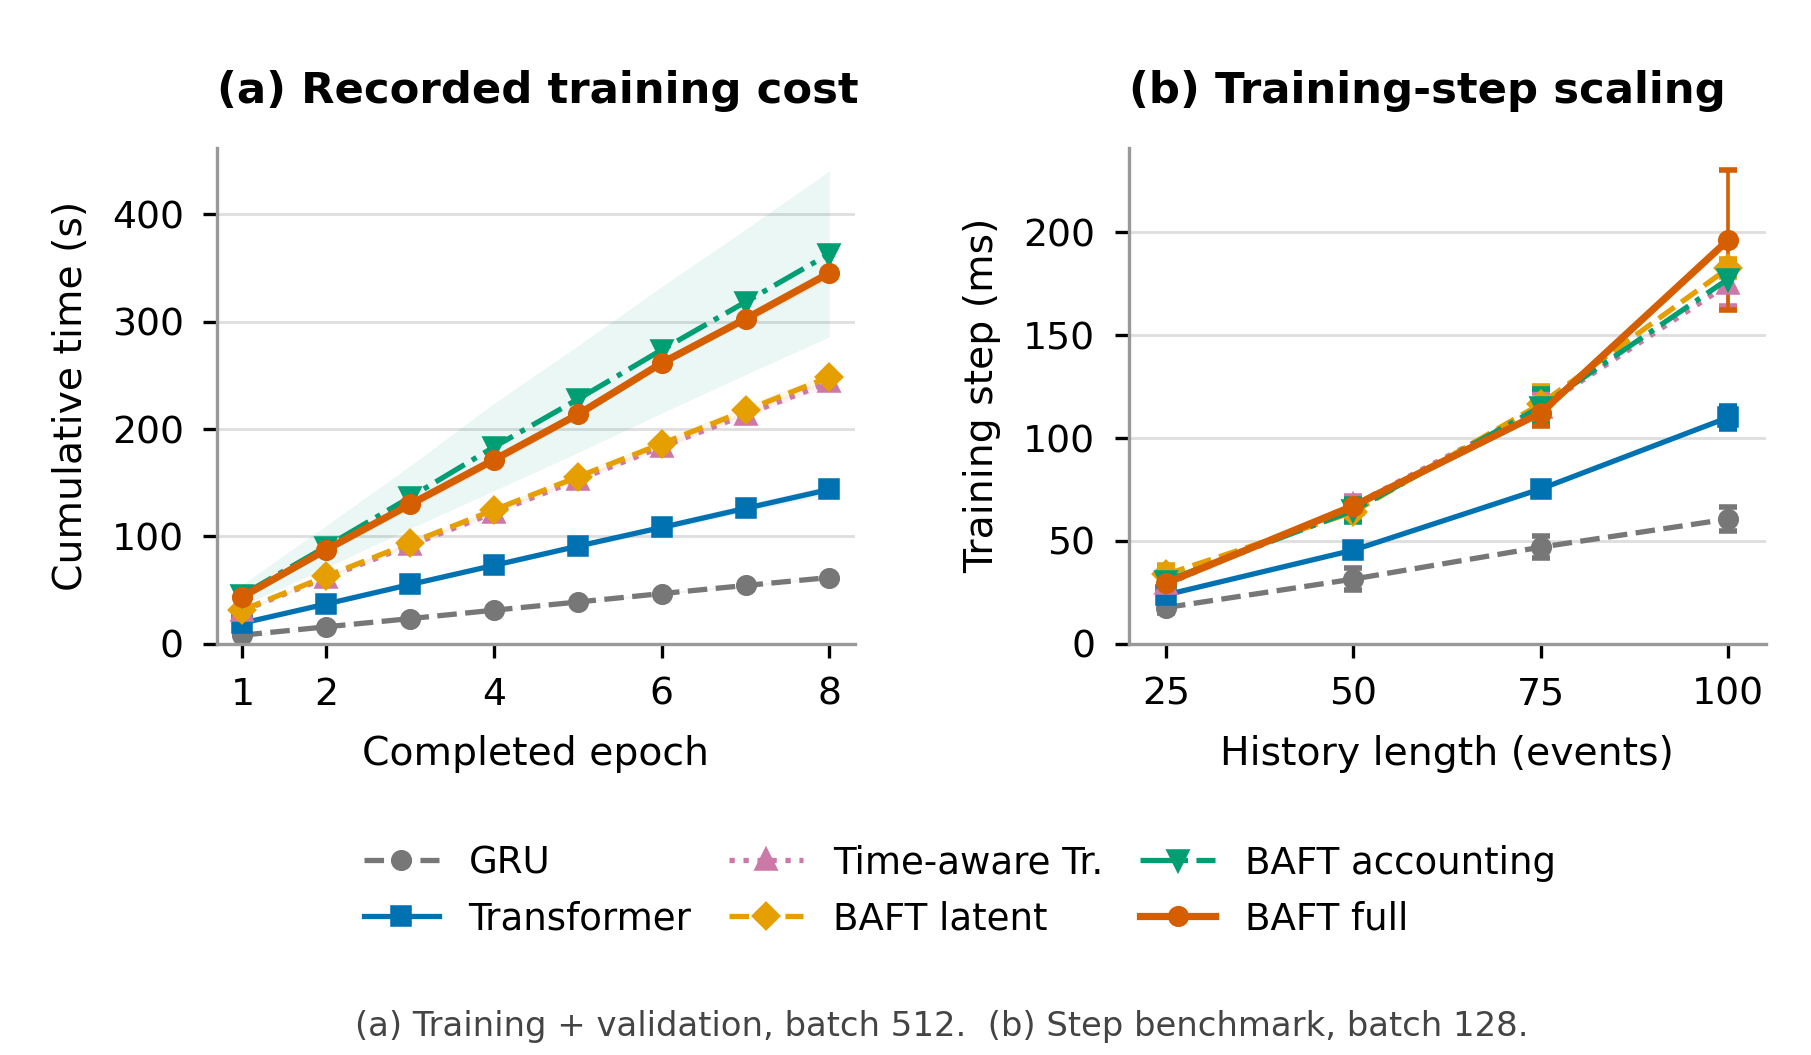

BAFT/Transformer recorded training-time ratio: 2.40× (paper rounding: 2.4×).


In [16]:
figure2 = plots.plot_efficiency(epoch_summary, scaling, OUT / 'figures')
display(Image(filename=str(figure2['png']), width=850))
times = training_cost.set_index('model')['cumulative_seconds_mean']
ratio = times['baft_full'] / times['transformer']
print(f'BAFT/Transformer recorded training-time ratio: {ratio:.2f}× (paper rounding: {ratio:.1f}×).')

## 6. Quantitative statements in the paper

The reductions below use the standard Transformer as comparator, under the same inference condition. Non-inferiority and classification superiority are different claims. The paper reports improvements in financial and latent coherence; it does not report classification or financially valid accuracy superiority.

In [17]:
headline_rows = []
for label,metric,condition in [('Operational residual MAE','operational_accounting_residual_mae',NATIVE),
                               ('Balance MAE','balance_mae',NATIVE),
                               ('Latent acceleration MSE','latent_acceleration_mse','latent_native')]:
    baseline, baft = item('transformer',metric,condition)['estimate'], item('baft_full',metric,condition)['estimate']
    headline_rows.append({'Endpoint':label,'Transformer':baseline,'BAFT full':baft,'Relative reduction (%)':100*(baseline-baft)/baseline})
headlines = pd.DataFrame(headline_rows)
headlines.to_csv(OUT / 'tables/headline_reductions.csv', index=False)
display(headlines.style.hide(axis='index').format({'Transformer':'{:.2f}','BAFT full':'{:.2f}','Relative reduction (%)':'{:.1f}'}))
print(f"Next-service accuracy: BAFT {100*item('baft_full','accuracy')['estimate']:.2f}%; Transformer {100*item('transformer','accuracy')['estimate']:.2f}%.")
print(f"Non-inferiority p = {ni['noninferiority_seed_t_p_one_sided']:.4f}; training cost ratio = {ratio:.1f}×.")

Endpoint,Transformer,BAFT full,Relative reduction (%)
Operational residual MAE,150.22,9.75,93.5
Balance MAE,163.90,54.68,66.6
Latent acceleration MSE,25.21,2.19,91.3


Next-service accuracy: BAFT 54.60%; Transformer 54.66%.
Non-inferiority p = 0.0023; training cost ratio = 2.4×.


## Reproducibility boundary

By default, this notebook is the **executed evaluation and figure-generation stage**. It recomputes the paper's statistics from saved predictions and latent measurements and regenerates its curves from recorded timings. The supplied execution does not repeat the 35 model fits.

The actual transaction archive and the original scientific training source are now included in [training/](training/README.md). The early dataset-access cell verifies file hashes and previews the CSV. Independent training is available through the disabled-by-default training cell or the documented command-line launcher. New fits, logs and predictions are saved separately and do not automatically replace the supplied paper evidence. The package does not promise identical training outcomes or timings on another system.


